<a href="https://colab.research.google.com/github/23064088/DataMiningGroup18/blob/naive-bayes/Naive_Bayes_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# --- 1. Imports ---
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# --- 2. Load the enriched dataset ---
file_path = "/content/sample_data/Financial_Data_New_With_Sentiment.csv"
df = pd.read_csv(file_path)
print("✅ Dataset loaded")
df.head()

✅ Dataset loaded


,id_num,age,monthly_income,credit_score,loan_amount,interest_rate,debt_to_income_ratio,late_payment_count_12m,financial_confidence,bank_type,risk_keywords_present,customer_statement,loan_default,risk_flag,Sentiment_Score
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,59,3360,578,43158,19.639879,12.844643,0,Medium,Traditional,0,I am writing to report financial difficulties ...,1,2,0.500000
1,23b8c1e9-3924-46de-beb1-3b9046685257,42,3269,648,7433,8.636499,2.273784,0,Low,Traditional,0,I want to invest my savings in the very moment...,0,0,0.500000
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,62,4547,718,7747,12.327237,1.703761,0,Medium,Digital,0,I want to invest my savings in the next year. ...,1,0,0.500000
3,972a8469-1641-4f82-8b9d-2434e465e150,41,7893,667,15627,23.844035,1.979856,1,Medium,Traditional,0,I want to invest my savings in the next year. ...,0,0,0.500000
4,17fc695a-07a0-4a6e-8822-e8f36c031199,64,3275,573,49974,8.467293,15.259237,1,Low,Traditional,0,I am writing to report financial difficulties ...,1,2,0.313378


In [4]:
# --- 3. Prepare features and target ---
# Use numeric features + Sentiment_Score
# Replace with your actual target column (e.g., loan_default, risk_flag)
features = ['monthly_income', 'credit_score', 'loan_amount',
            'debt_to_income_ratio', 'late_payment_count_12m', 'Sentiment_Score']
target = 'loan_default'  # replace if you want risk_flag or other

X = df[features]
y = df[target]

In [5]:
# --- 4. Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# --- 5. Initialize & train Gaussian Naive Bayes ---
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

In [7]:
# --- 6. Predict & evaluate ---
y_pred = gnb.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.73

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.81      0.73       180
           1       0.81      0.66      0.73       220

    accuracy                           0.73       400
   macro avg       0.74      0.74      0.73       400
weighted avg       0.74      0.73      0.73       400



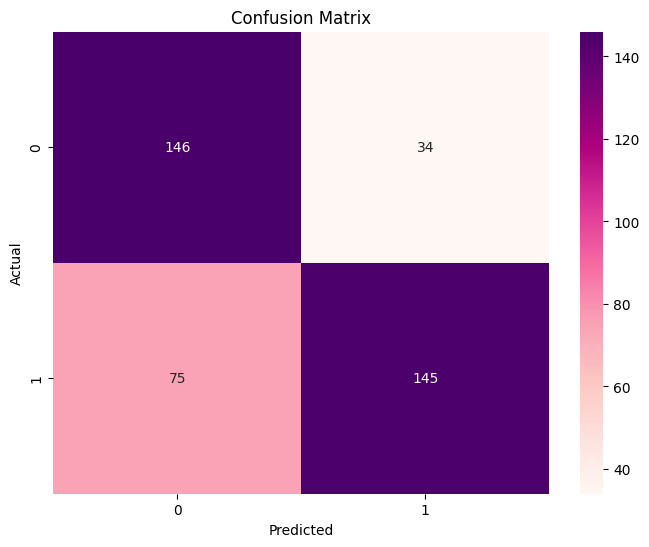

In [8]:
# --- 7. Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()